# Few-shot k=1 prompts (3 random-demo seeds) vs. baselines

Summary of the `final_k1_test` / `final_k1_heldout` sweeps (2026-08-31) against the canonical
empty-prompt baselines. Prompts: `fewshot/final_prompts/{model}/k1_s{1,2,3}.txt` — one
verified-compliant demo per constraint mode drawn uniformly at random from the SFT positive
datasets (`sft/training_data/{model}`), mode order shuffled per seed, family-native reasoning
rendering. All numbers are on the canonical **test split** (main eval n=4464: 3 datasets x 9
modes; held-out eval n=1500: 3 modes never demonstrated in the prompt).

**Few-shot bars show the best of the 3 prompt seeds** (selected by strict compliance on the
9-mode main eval), because the question is *elicitation*: what controllability a k=1 prompt
can reach, for which best-of-N is the right statistic. Demo choice is a first-order variable
(seed spread up to ~2x within a cell), so small dots show all 3 individual seeds. Selection-on-
test inflation is negligible: test SE ~ 0.006 at n=4464, so max-of-3 inflates by <~0.01.
The held-out bars use the **same pre-decided seed** (chosen on the main eval, never on the
held-out modes), so they are an unbiased transfer measure.

- **Baseline**: empty system prompt (`baselines/<model>/baseline_results.json`), single run
- **Few-shot (k=1)**: 9-demo system prompt, best of 3 random-demo seeds

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().resolve()
if REPO.name == "fewshot":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from utils import PALETTE, set_matplotlib_style

set_matplotlib_style()

In [3]:
# (dir key, display name) — sorted by best few-shot strict compliance (best of 3 seeds)
MODELS = [
    ("kimik3", "Kimi-K3"),
    ("gptoss120b", "GPT-OSS-120B"),
    ("qwen32b", "Qwen3-32B"),
    ("dsv4pro", "DeepSeek-V4-Pro"),
    ("gptoss20b", "GPT-OSS-20B"),
    ("qwen8b", "Qwen3-8B"),
    ("glm53", "GLM-5.3"),
    ("glm53flash", "GLM-5.3-Flash"),
]
SEEDS = ["s1", "s2", "s3"]

ARMS = [
    ("baseline", "Baseline (empty prompt)", PALETTE[0]),
    ("fewshot", "Few-shot k=1 (9 demos)", PALETTE[1]),
]


def summary(grp, key, seed):
    with open(REPO / "fewshot/runs" / grp / f"{key}_{seed}" / "summary.json") as f:
        return json.load(f)


def baseline_results(key, heldout=False):
    d = f"{key}_heldout" if heldout else key
    with open(REPO / "baselines" / d / "baseline_results.json") as f:
        return json.load(f)


rows = []
for key, name in MODELS:
    row = {"key": key, "name": name}
    row["baseline_strict_compliance"] = baseline_results(key)["overall"]["strict_compliance"]
    strict = {s: summary("final_k1_test", key, s)["compliance_rate"] for s in SEEDS}
    row["best_seed"] = max(strict, key=strict.get)
    row["fewshot_strict_compliance"] = strict[row["best_seed"]]
    row["seeds_strict_compliance"] = strict
    rows.append(row)

for r in rows:
    ss = r["seeds_strict_compliance"]
    print(f"{r['name']:<16} strict {r['baseline_strict_compliance']:.3f} -> "
          f"fewshot {r['fewshot_strict_compliance']:.3f} [{r['best_seed']}] "
          f"({'/'.join(f'{ss[s]:.3f}' for s in SEEDS)})")

Kimi-K3          strict 0.049 -> fewshot 0.345 [s1] (0.345/0.320/0.310)
GPT-OSS-120B     strict 0.042 -> fewshot 0.332 [s2] (0.208/0.332/0.293)
Qwen3-32B        strict 0.023 -> fewshot 0.198 [s2] (0.144/0.198/0.160)
DeepSeek-V4-Pro  strict 0.008 -> fewshot 0.162 [s1] (0.162/0.145/0.088)
GPT-OSS-20B      strict 0.009 -> fewshot 0.157 [s2] (0.071/0.157/0.117)
Qwen3-8B         strict 0.011 -> fewshot 0.135 [s2] (0.127/0.135/0.122)
GLM-5.3          strict 0.052 -> fewshot 0.041 [s3] (0.031/0.022/0.041)
GLM-5.3-Flash    strict 0.025 -> fewshot 0.029 [s3] (0.014/0.012/0.029)


# Summary: baseline vs few-shot, main and held-out modes

One aggregate view before the per-mode breakdowns: for each model, strict compliance under the
empty prompt and under the best k=1 few-shot prompt, on the 9 demonstrated modes (n=4464) and
on the 3 held-out modes (n=1500). Few-shot bars use the seed selected on the **main** eval
(so the held-out bar is an unbiased transfer number); dots show all 3 seeds. Lighter bars are
the held-out evals.

saved /root/controllability-elicitation/fewshot/analysis/summary_vs_baselines.png


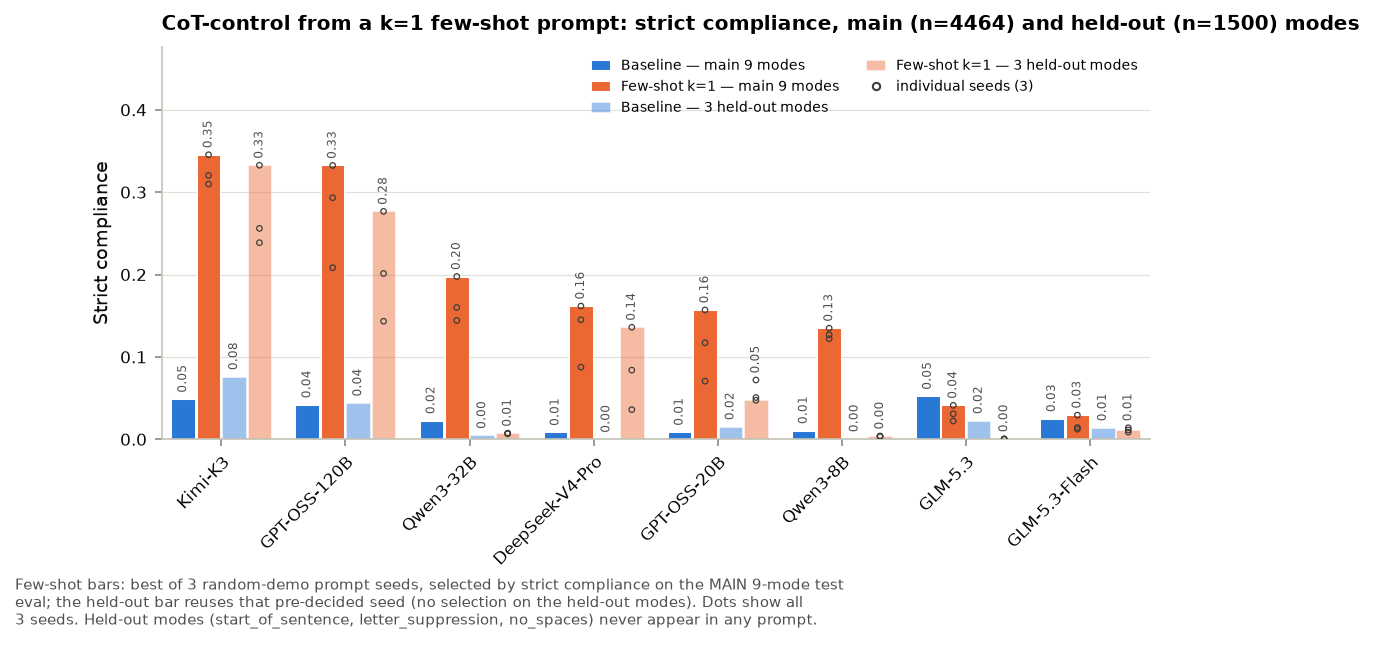

In [4]:
ho_rows = []
for r in rows:
    seeds_ho = {s: summary("final_k1_heldout", r["key"], s)["compliance_rate"] for s in SEEDS}
    ho_rows.append({
        "baseline_heldout": baseline_results(r["key"], heldout=True)["overall"]["strict_compliance"],
        "fewshot_heldout": seeds_ho[r["best_seed"]],
        "seeds_heldout": seeds_ho,
    })

BARS = [  # (label, value fn, seed-dict key or None, color, alpha)
    ("Baseline — main 9 modes", lambda r, h: r["baseline_strict_compliance"],
     None, PALETTE[0], 1.0),
    ("Few-shot k=1 — main 9 modes", lambda r, h: r["fewshot_strict_compliance"],
     "main", PALETTE[1], 1.0),
    ("Baseline — 3 held-out modes", lambda r, h: h["baseline_heldout"],
     None, PALETTE[0], 0.45),
    ("Few-shot k=1 — 3 held-out modes", lambda r, h: h["fewshot_heldout"],
     "heldout", PALETTE[1], 0.45),
]

x = np.arange(len(rows))
width = 0.19

fig, ax = plt.subplots(figsize=(8.5, 3.4))
for i, (label, fn, dots, color, alpha) in enumerate(BARS):
    vals = [fn(r, h) for r, h in zip(rows, ho_rows)]
    offs = x + (i - 1.5) * (width + 0.015)
    bars = ax.bar(offs, vals, width, label=label, color=color, alpha=alpha,
                  edgecolor="white", linewidth=0.5)
    for xi, r, h, v in zip(offs, rows, ho_rows, vals):
        sv = []
        if dots:  # per-seed dots (bar = the main-eval-best seed)
            sv = list((r["seeds_strict_compliance"] if dots == "main"
                       else h["seeds_heldout"]).values())
            ax.scatter([xi] * len(sv), sv, s=7, facecolors="none",
                       edgecolors="#3d3d3a", linewidths=0.6, zorder=3)
        # value label above the bar AND any seed dots, so they never collide
        ax.text(xi, max([v] + sv) + 0.008, f"{v:.2f}", rotation=90, ha="center",
                va="bottom", fontsize=5.6, color="#52514e", zorder=4)

ax.set_ylabel("Strict compliance")
ax.set_title("CoT-control from a k=1 few-shot prompt: strict compliance, main (n=4464) "
             "and held-out (n=1500) modes", fontsize=9.5, pad=8)
top = max(max(list(r["seeds_strict_compliance"].values())
              + list(h["seeds_heldout"].values())
              + [r["baseline_strict_compliance"], h["baseline_heldout"]])
          for r, h in zip(rows, ho_rows))
ax.set_ylim(0, top * 1.38)  # headroom for the rotated bar labels
ax.margins(x=0.01)
ax.set_xticks(x, [r["name"] for r in rows], rotation=45, ha="right",
              rotation_mode="anchor")

seed_handle = plt.Line2D([], [], marker="o", ls="none", ms=3.5, markerfacecolor="none",
                         markeredgecolor="#3d3d3a", label="individual seeds (3)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [seed_handle], labels + ["individual seeds (3)"],
          ncols=2, loc="upper right", fontsize=6.5)

fig.text(0.01, -0.16,
         "Few-shot bars: best of 3 random-demo prompt seeds, selected by strict compliance on the MAIN 9-mode test\n"
         "eval; the held-out bar reuses that pre-decided seed (no selection on the held-out modes). Dots show all\n"
         "3 seeds. Held-out modes (start_of_sentence, letter_suppression, no_spaces) never appear in any prompt.",
         fontsize=7, color="#52514e", va="top")

out = REPO / "fewshot/analysis/summary_vs_baselines.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()

# Per-mode breakdown: baseline vs few-shot on the 9 demonstrated modes

Strict compliance on each of the 9 reasoning-control modes (test split, ~500 rollouts per
mode), one subplot per model, two bars per mode (baseline / few-shot best-of-3-seeds). Dots
show the individual prompt seeds — per-mode seed spread is where the aggregate variance
comes from (`ignore_question` and `repeat_sentences` especially).

saved /root/controllability-elicitation/fewshot/analysis/per_mode_compliance.png


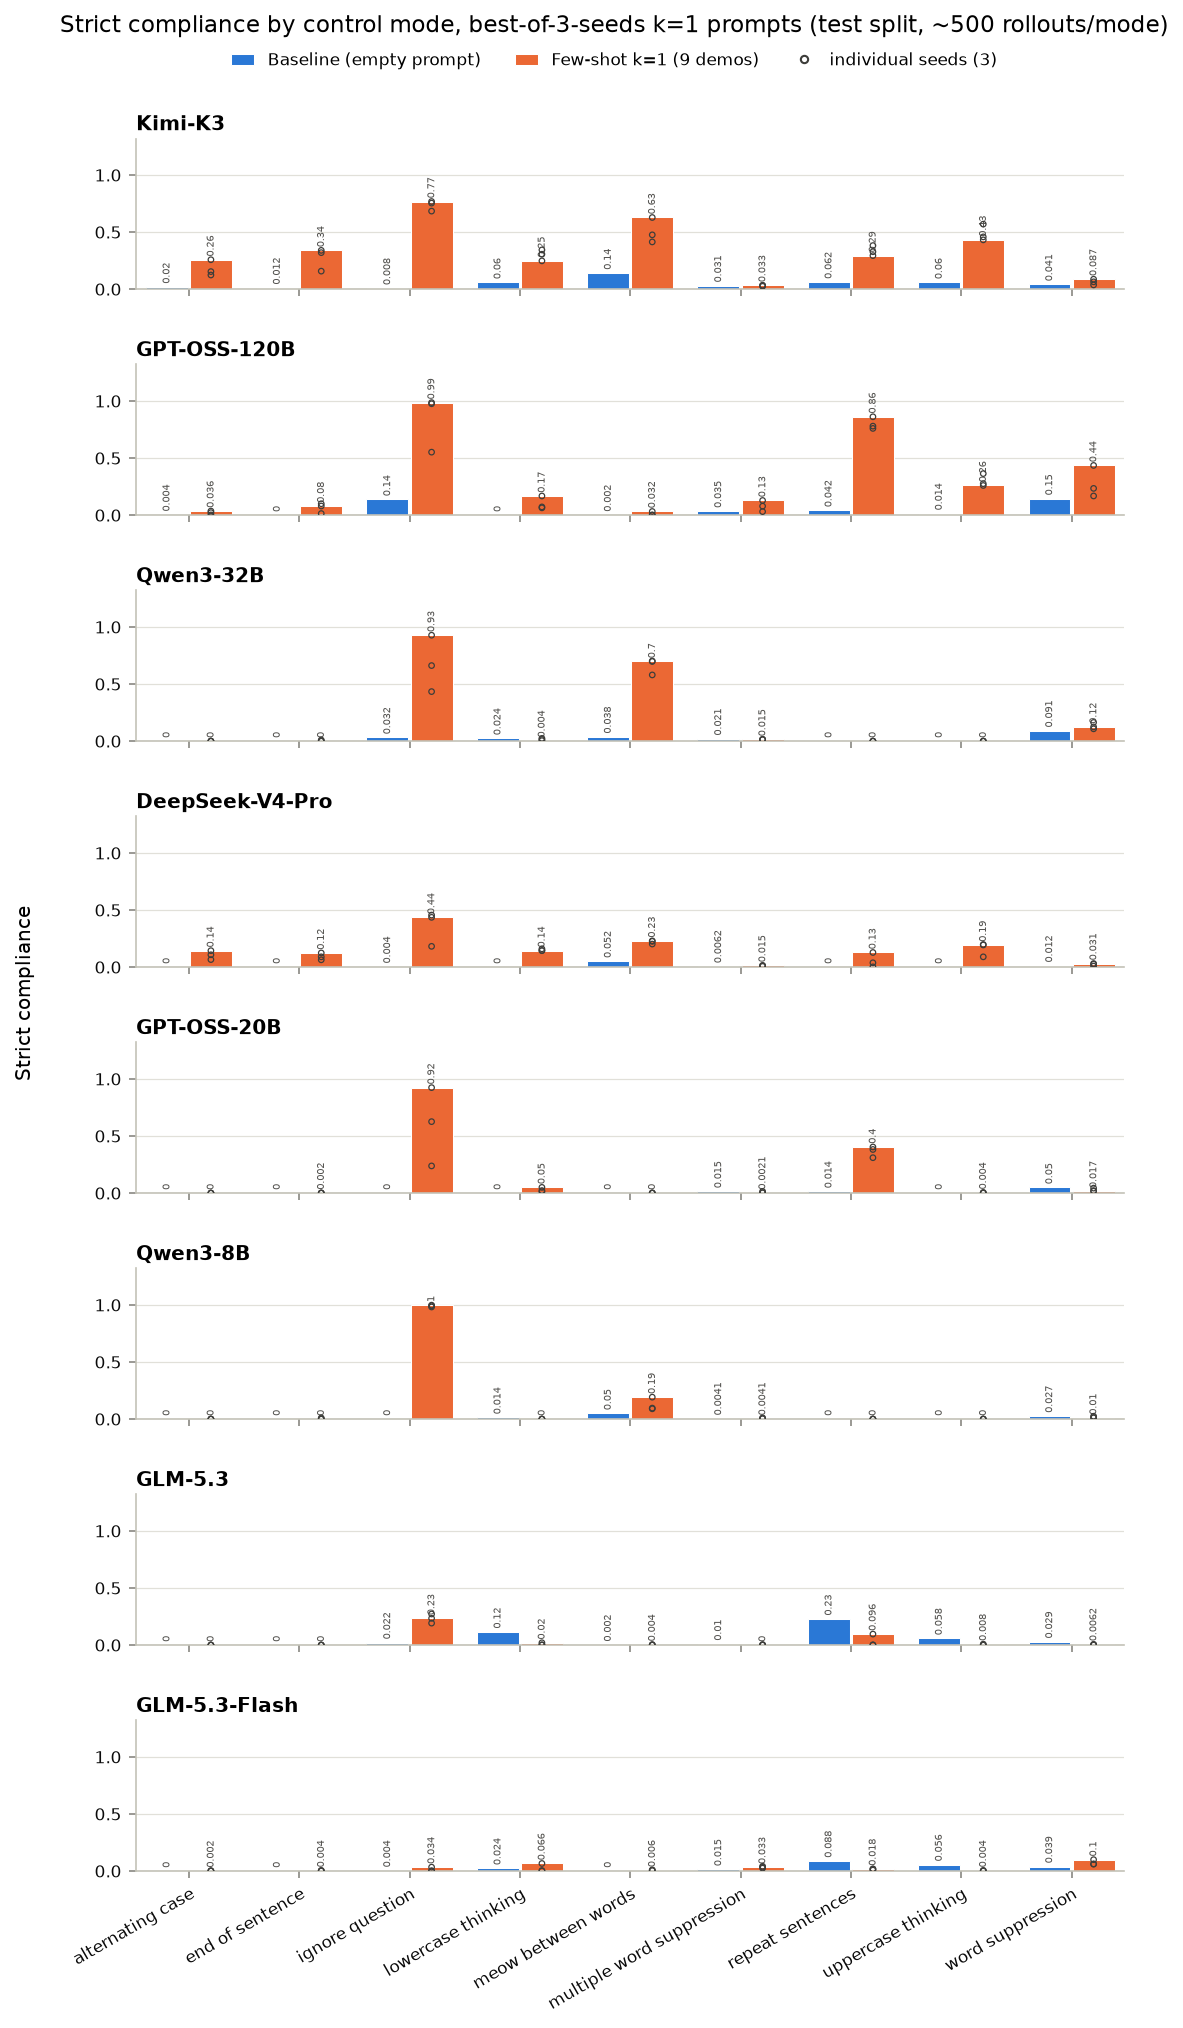

In [5]:
def per_mode_strict(grp, key, seed):
    pm = summary(grp, key, seed)["per_mode"]
    return {m: v["compliant"] / v["n"] for m, v in pm.items()}


def baseline_per_mode(key, heldout=False):
    pm = baseline_results(key, heldout)["per_mode"]
    return {m: v["strict_compliance"] for m, v in pm.items()}


best = {r["key"]: r["best_seed"] for r in rows}
MODES = sorted(baseline_per_mode(MODELS[0][0]))

xm = np.arange(len(MODES))
width = 0.38

fig, axes = plt.subplots(len(MODELS), 1, figsize=(8.5, 15), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.5})

for ax, (key, name) in zip(axes, MODELS):
    pm_seeds = {s: per_mode_strict("final_k1_test", key, s) for s in SEEDS}
    for i, (arm, label, color) in enumerate(ARMS):
        vals = ([baseline_per_mode(key)[m] for m in MODES] if arm == "baseline"
                else [pm_seeds[best[key]][m] for m in MODES])
        offs = xm + (i - 0.5) * (width + 0.02)
        bars = ax.bar(offs, vals, width, label=label, color=color,
                      edgecolor="white", linewidth=0.5)
        ax.bar_label(bars, labels=[f"{v:.2g}" for v in vals], fontsize=5,
                     color="#52514e", rotation=90, padding=1.5)
        if arm == "fewshot":  # per-seed dots (bar = best-of-3 on the main eval)
            for xi, m in zip(offs, MODES):
                sv = [pm_seeds[s][m] for s in SEEDS]
                ax.scatter([xi] * len(sv), sv, s=7, facecolors="none",
                           edgecolors="#3d3d3a", linewidths=0.6, zorder=3)
    ax.set_title(name, fontsize=9.5, pad=4)
    ax.set_ylim(0, 1.32)  # headroom for the rotated bar labels
    ax.set_yticks([0, 0.5, 1])
    ax.margins(x=0.01)

axes[-1].set_xticks(xm, [m.replace("_", " ") for m in MODES], rotation=30,
                    ha="right", rotation_mode="anchor")
fig.supylabel("Strict compliance", fontsize=9.5, x=0.03)

seed_handle = plt.Line2D([], [], marker="o", ls="none", ms=3.5, markerfacecolor="none",
                         markeredgecolor="#3d3d3a", label="individual seeds (3)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles + [seed_handle], labels + ["individual seeds (3)"], ncols=3,
           loc="upper center", bbox_to_anchor=(0.5, 0.925), frameon=False)
fig.suptitle("Strict compliance by control mode, best-of-3-seeds k=1 prompts "
             "(test split, ~500 rollouts/mode)", y=0.935, fontsize=11)

out = REPO / "fewshot/analysis/per_mode_compliance.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()

# Transfer to held-out control modes

Do k=1 few-shot prompts elicit *general* CoT controllability, or only skill at the 9
demonstrated modes? Every prompt is evaluated on the 3 **held-out modes**
(`start_of_sentence`, `letter_suppression`, `no_spaces`) that never appear in any prompt —
500 test questions x 3 modes = 1500 rollouts per run (sweep `final_k1_heldout`; held-out
baselines in `baselines/<model>_heldout/`).

**Each few-shot bar is one pre-decided prompt per model**: the seed with the highest strict
compliance on the *main* test eval — the prompt you would have shipped before ever seeing the
held-out modes. Dots show all 3 seeds. Reading: kimi/gpt-oss transfer most of their
in-distribution gain to never-demonstrated modes; the qwen models transfer nothing despite
real in-distribution compliance; the GLMs are inert everywhere.

saved /root/controllability-elicitation/fewshot/analysis/heldout_per_mode.png


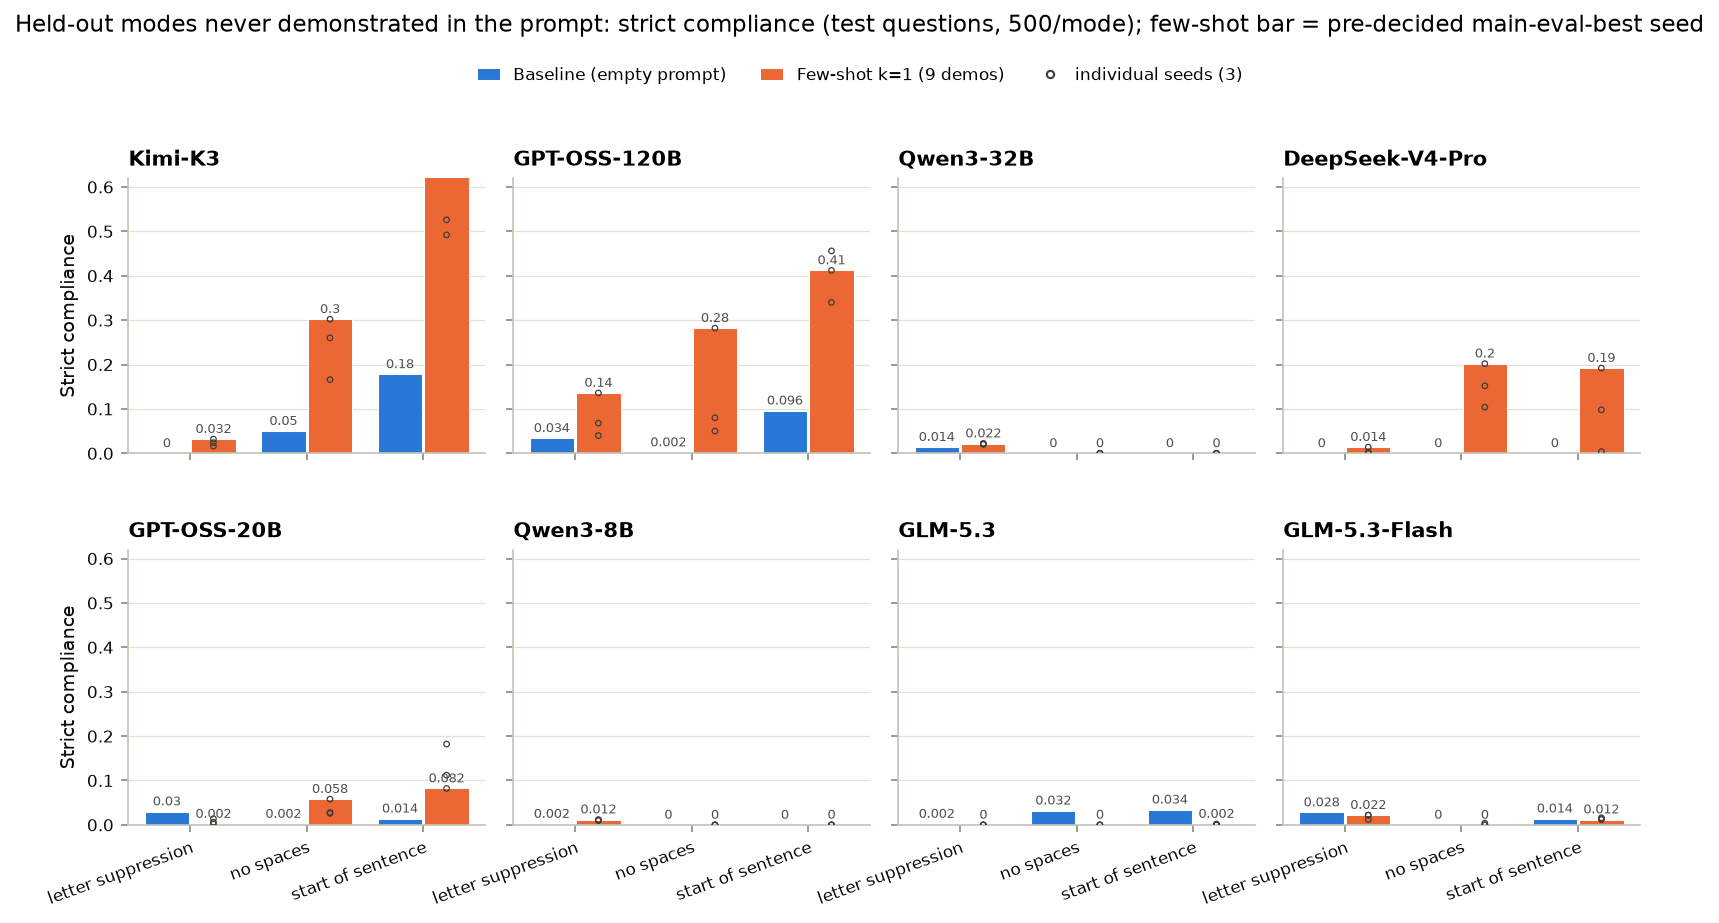

In [6]:
xm3 = None
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.35, "wspace": 0.08})

HO_MODES = sorted(baseline_per_mode(MODELS[0][0], heldout=True))
xm3 = np.arange(len(HO_MODES))

for ax, (key, name) in zip(axes.flat, MODELS):
    pm_seeds = {s: per_mode_strict("final_k1_heldout", key, s) for s in SEEDS}
    for i, (arm, label, color) in enumerate(ARMS):
        vals = ([baseline_per_mode(key, heldout=True)[m] for m in HO_MODES]
                if arm == "baseline" else [pm_seeds[best[key]][m] for m in HO_MODES])
        offs = xm3 + (i - 0.5) * (width + 0.02)
        bars = ax.bar(offs, vals, width, label=label, color=color,
                      edgecolor="white", linewidth=0.5)
        for t in ax.bar_label(bars, labels=[f"{v:.2g}" for v in vals], fontsize=6,
                              color="#52514e", padding=1.5):
            t.set_zorder(4)
        if arm == "fewshot":  # per-seed dots (bar = the main-eval-best seed)
            for xi, m in zip(offs, HO_MODES):
                sv = [pm_seeds[s][m] for s in SEEDS]
                ax.scatter([xi] * len(sv), sv, s=7, facecolors="none",
                           edgecolors="#3d3d3a", linewidths=0.6, zorder=3)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(0, 0.62)
    ax.margins(x=0.05)

for ax in axes[1]:
    ax.set_xticks(xm3, [m.replace("_", " ") for m in HO_MODES], rotation=20,
                  ha="right", rotation_mode="anchor")
for ax in axes[:, 0]:
    ax.set_ylabel("Strict compliance")

seed_handle = plt.Line2D([], [], marker="o", ls="none", ms=3.5, markerfacecolor="none",
                         markeredgecolor="#3d3d3a", label="individual seeds (3)")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles + [seed_handle], labels + ["individual seeds (3)"], ncols=3,
           loc="upper center", bbox_to_anchor=(0.5, 1.03), frameon=False)
fig.suptitle("Held-out modes never demonstrated in the prompt: strict compliance "
             "(test questions, 500/mode); few-shot bar = pre-decided main-eval-best seed",
             y=1.075, fontsize=11)

out = REPO / "fewshot/analysis/heldout_per_mode.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()

# Compliance vs. reasoning length: are few-shot prompts just shortening the CoT?

Few-shot prompts could raise strict compliance simply by making traces shorter (fewer chances
to slip on absence-type constraints). To disambiguate, we plot per-rollout strict compliance
against reasoning length (log-spaced word-count bins, pooled over modes/datasets), one subplot
per model, baseline vs few-shot. If the few-shot curve sits **above baseline at the same
length**, the gain is not just a length effect.

All 3 prompt seeds are shown: the **best-of-3 run** (the one the bar plots use) is drawn at
full weight with binomial-SE error bars; the other two seeds are thin faded lines. Data:
`fewshot/analysis/length_compliance_cache.parquet`, built from the per-rollout test-split eval
JSONs by `fewshot/analysis/extract_length_compliance.py` (re-run if missing/stale). Bins with
fewer than 50 rollouts are dropped.

**Caveats** (as in the GEPA notebook): bins pool the 9 modes, so mode composition varies along
x; length is on-policy, not randomized, so within-arm slopes are correlational.

saved /root/controllability-elicitation/fewshot/analysis/compliance_vs_length.png


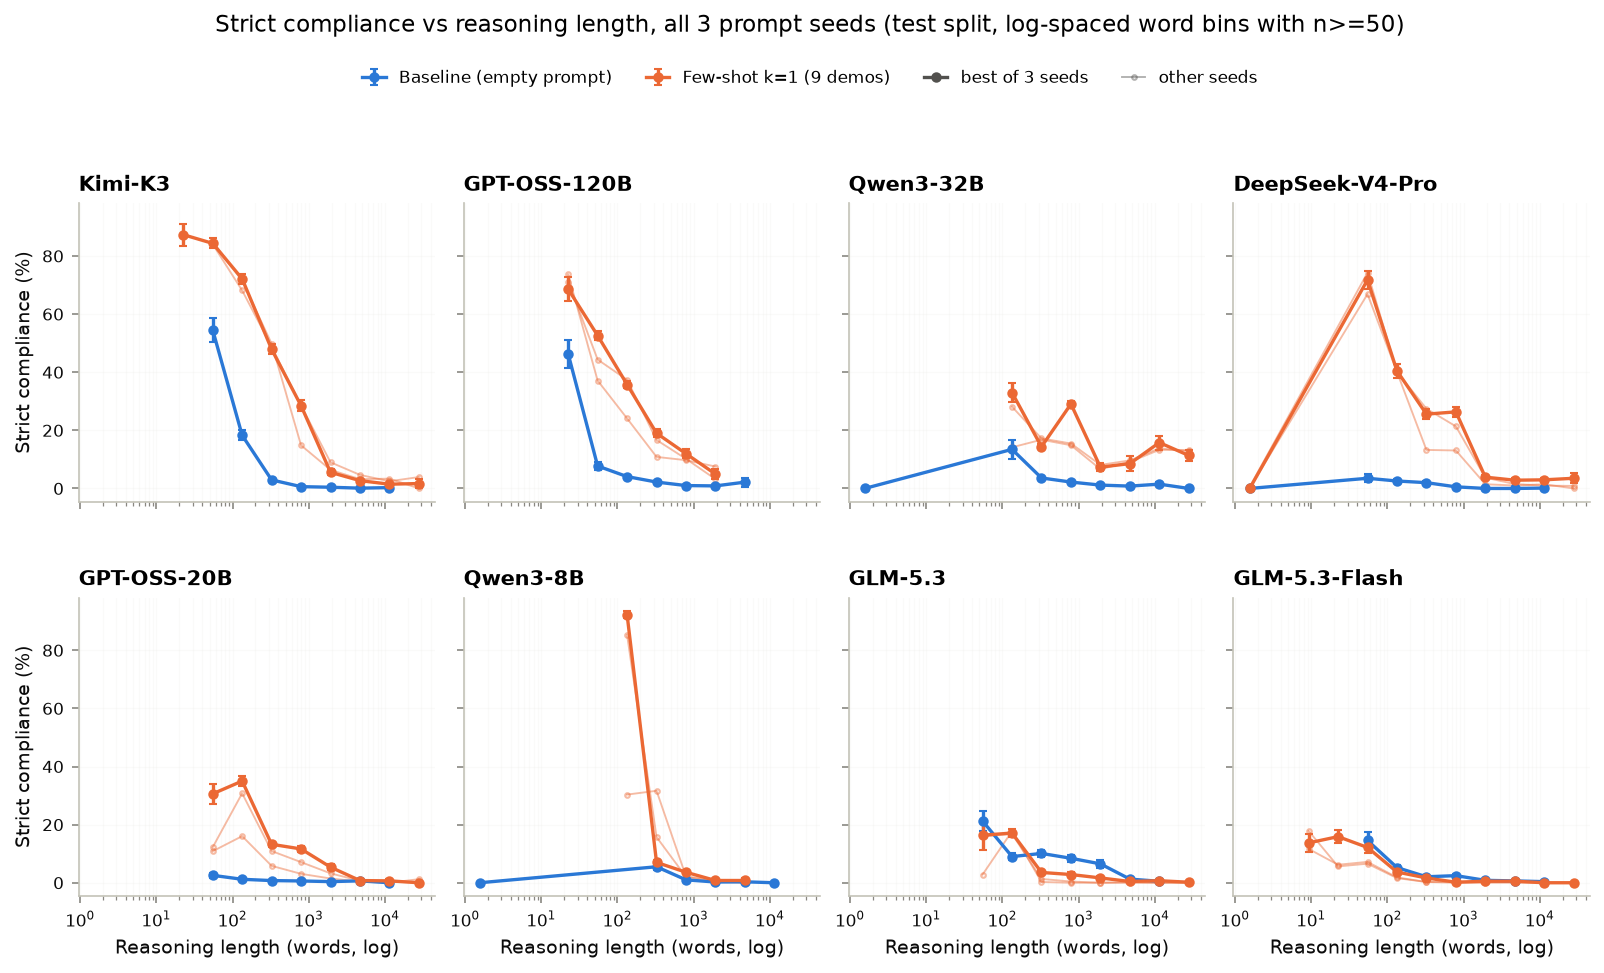

In [7]:
import pandas as pd

MIN_BIN_N = 50

cache = pd.read_parquet(REPO / "fewshot/analysis/length_compliance_cache.parquet")
df = cache.copy()
df["reasoning_words"] = df["reasoning_words"].clip(lower=1)

# Global log-spaced bins so curves are comparable across arms, seeds, and models.
bins = np.geomspace(1, df["reasoning_words"].max() * 1.001, 14)


def binned(sub):
    """(bin geometric center, mean compliance, binomial SE, n) per bin with n >= MIN_BIN_N."""
    idx = np.digitize(sub["reasoning_words"], bins) - 1
    out = []
    for b in range(len(bins) - 1):
        m = idx == b
        n = int(m.sum())
        if n < MIN_BIN_N:
            continue
        p = sub.loc[m, "compliance"].mean()
        out.append((np.sqrt(bins[b] * bins[b + 1]), p, np.sqrt(p * (1 - p) / n), n))
    return np.array(out).reshape(-1, 4)


fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.32, "wspace": 0.08})

for ax, (key, name) in zip(axes.flat, MODELS):
    mdf = df[df["model"] == key]
    for arm, label, color in ARMS:
        adf = mdf[mdf["arm"] == arm]
        for s in (["-"] if arm == "baseline" else SEEDS):
            pts = binned(adf[adf["seed"] == s])
            if not len(pts):
                continue
            cx, p, se, n = pts.T
            if arm == "baseline" or s == best[key]:
                ax.errorbar(cx, 100 * p, yerr=100 * se, color=color, label=label,
                            marker="o", ms=4, lw=1.6, capsize=2)
            else:  # non-best seeds: thin faded lines in the same arm color
                ax.plot(cx, 100 * p, color=color, lw=0.9, alpha=0.45,
                        marker="o", ms=2.2, markerfacecolor="none")
    ax.set_xscale("log")
    ax.set_title(name, fontsize=10)
    ax.grid(True, which="both", alpha=0.15)

for ax in axes[1]:
    ax.set_xlabel("Reasoning length (words, log)")
for ax in axes[:, 0]:
    ax.set_ylabel("Strict compliance (%)")

handles, labels = axes.flat[0].get_legend_handles_labels()
handles += [plt.Line2D([], [], color="#52514e", lw=1.6, marker="o", ms=4),
            plt.Line2D([], [], color="#52514e", lw=0.9, alpha=0.45, marker="o",
                       ms=2.2, markerfacecolor="none")]
labels += ["best of 3 seeds", "other seeds"]
fig.legend(handles, labels, ncols=4, loc="upper center",
           bbox_to_anchor=(0.5, 1.045), frameon=False)
fig.suptitle("Strict compliance vs reasoning length, all 3 prompt seeds "
             f"(test split, log-spaced word bins with n>={MIN_BIN_N})",
             y=1.09, fontsize=11)

out = REPO / "fewshot/analysis/compliance_vs_length.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()

# The k1-k4 grid: compliance vs number of shots per mode, all 8 models

Strict compliance against k (demos per mode) for the full 8-model x k1-k4 sweep
(`fewshot/runs/promptscale/` + `fewshot/runs/remaining4/`; single fixed prompt per
(model, k), not the 3-seed protocol above). Each curve is anchored at k=0 on the model's
empty-prompt baseline. All cells <2% errors except qwen32b k4 (3.3%, provider timeouts;
its ~0.20 level is corroborated by two independent discarded reruns).

Reading: one shot per mode buys almost the entire effect everywhere; beyond k=1 the curves
are flat (gptoss20b, qwen8b, dsv4pro), declining from a high intercept (gpt-oss-120b,
kimi-k3), or inert (both GLMs). **qwen3-32b is the lone riser** (.11 -> .20).

saved /root/controllability-elicitation/fewshot/analysis/k_grid.png


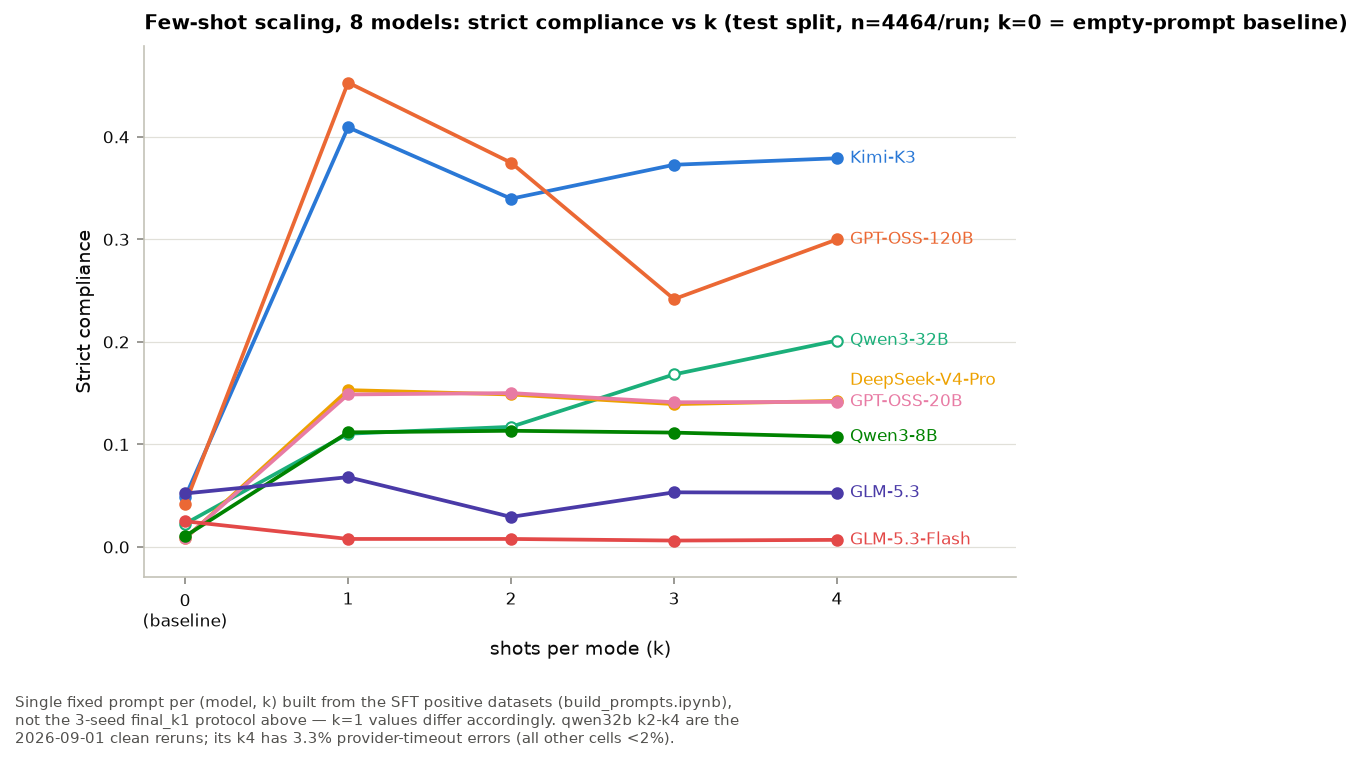

In [8]:
GRID_KS = [1, 2, 3, 4]


def grid_summary(key, k):
    hits = list((REPO / "fewshot/runs").glob(f"*/{key}_k{k}/summary.json"))
    assert len(hits) == 1, (key, k, hits)
    with open(hits[0]) as f:
        return json.load(f)


fig, ax = plt.subplots(figsize=(7.5, 4.6))
ends = []
for (key, name), color in zip(MODELS, PALETTE):
    base = baseline_results(key)["overall"]["strict_compliance"]
    ys = [base] + [grid_summary(key, k)["compliance_rate"] for k in GRID_KS]
    ax.plot([0] + GRID_KS, ys, "-o", color=color, ms=5, lw=1.8, label=name,
            markerfacecolor="white" if key == "qwen32b" else None)
    ends.append((ys[-1], name, color))

# direct labels at the line ends, nudged apart where models collide
ends.sort()
last_y = -1
for y, name, color in ends:
    ly = max(y, last_y + 0.021)
    last_y = ly
    ax.annotate(name, (4.08, ly), color=color, fontsize=8, va="center")

ax.set_xticks([0] + GRID_KS, ["0\n(baseline)"] + [str(k) for k in GRID_KS])
ax.set_xlim(-0.25, 5.1)
ax.set_xlabel("shots per mode (k)")
ax.set_ylabel("Strict compliance")
ax.set_title("Few-shot scaling, 8 models: strict compliance vs k "
             "(test split, n=4464/run; k=0 = empty-prompt baseline)",
             fontsize=9.5, pad=8)
ax.margins(y=0.08)

fig.text(0.01, -0.06,
         "Single fixed prompt per (model, k) built from the SFT positive datasets (build_prompts.ipynb),\n"
         "not the 3-seed final_k1 protocol above — k=1 values differ accordingly. qwen32b k2-k4 are the\n"
         "2026-09-01 clean reruns; its k4 has 3.3% provider-timeout errors (all other cells <2%).",
         fontsize=7, color="#52514e", va="top")

out = REPO / "fewshot/analysis/k_grid.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()